In [1]:
import pandas as pd
import numpy as np
import pyarrow
from sklearn.model_selection import  train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import optimizers
import keras
import tensorflow as tf
from src import *

# Configurações 
print(tf.config.list_physical_devices())
BATCH_SIZE = 1024

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## **Função para encontrar o número máximo de neurônio**

In [2]:
def num_max_neuronio(X, d):
    CT = len(X)
    return int((CT - 10)/(10 * (d + 2)))

## **Leitura dos dados e adaptações necessárias para a rede neural**

In [3]:
colunas = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['NU_ANO', 'NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_MT']
    )
df = pd.read_parquet('dados acertos', columns=colunas)

In [4]:
df = calcular_acertos_por_area(df)

In [5]:
df_reduzido = df.sample(n=1_000_000, random_state=42)

In [6]:
df_reduzido['MEDIA_GERAL'] = (
    df_reduzido['ACERTOS_LC'] + 
    df_reduzido['ACERTOS_MT'] + 
    df_reduzido['ACERTOS_CH'] + 
    df_reduzido['ACERTOS_CN']
) / 4

df_reduzido['CLASSE'] = df_reduzido.groupby('NU_ANO')['MEDIA_GERAL'].transform(
    lambda x: pd.qcut(x, q=9, labels=[0, 1, 2,3,4,5,6,7,8])
).astype('Int64')

df_reduzido['CLASSE'] = df_reduzido['CLASSE'].astype(int)

In [7]:
features = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] 
    )

X = df_reduzido[features]
y = df_reduzido['CLASSE']


## **Separando os dados**

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

## **Normalizando os dados**

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train).astype(np.float32)
x_val   = scaler.transform(x_val).astype(np.float32)
x_test  = scaler.transform(x_test).astype(np.float32)

In [10]:
# Analisando os dados do rotulo de treinamento
print("Tipo:", y_train.dtype)
print("Valores únicos:", np.unique(y_train))
print("Amostra:", y_train[:10])

Tipo: int64
Valores únicos: [0 1 2 3 4 5 6 7 8]
Amostra: 4055185    5
5568612    8
1200247    5
3359342    5
714204     0
1443387    5
2480280    3
4657980    2
684442     5
867732     8
Name: CLASSE, dtype: int64


## **Construindo a rede neural**

In [11]:
max_neurons = num_max_neuronio(x_train, d = 1)
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 21333


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

model = Sequential()
model.add(Dense(100, input_dim=180,
                kernel_initializer='he_normal',
                
                activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(100, kernel_initializer='he_normal',
                
                activation='relu'))
#model.add(Dropout(0.2))

# Camada de saída
model.add(Dense(9, kernel_initializer='he_normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[es],
    verbose=1
)

Epoch 1/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.8341 - loss: 0.3824 - val_accuracy: 0.8962 - val_loss: 0.2353
Epoch 2/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8985 - loss: 0.2341 - val_accuracy: 0.9178 - val_loss: 0.1921
Epoch 3/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.9110 - loss: 0.2056 - val_accuracy: 0.9242 - val_loss: 0.1777
Epoch 4/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.9187 - loss: 0.1883 - val_accuracy: 0.9143 - val_loss: 0.1990
Epoch 5/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.9260 - loss: 0.1738 - val_accuracy: 0.9204 - val_loss: 0.1897
Epoch 6/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.9328 - loss: 0.1595 - val_accuracy: 0.9067 - val_loss: 0.2130
Epoch 7/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.9371 - loss: 0.1496 - val_accuracy: 0.9339 - val_loss: 0.1545
Epoch 8/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 

In [14]:
import numpy as np

y_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_pred))

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     23196
           1       0.94      0.94      0.94     22638
           2       0.98      0.88      0.92     22127
           3       0.91      0.98      0.94     21895
           4       0.97      0.95      0.96     23134
           5       0.95      0.94      0.95     21739
           6       0.94      0.94      0.94     21334
           7       0.94      0.93      0.94     22280
           8       0.94      1.00      0.97     21657

    accuracy                           0.95    200000
   macro avg       0.95      0.95      0.95    200000
weighted avg       0.95      0.95      0.95    200000



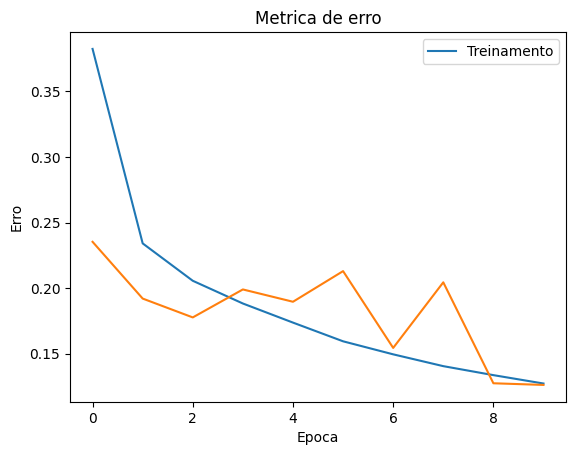

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9476 - loss: 0.1263

--> Acuracia (treino): 0.9538
--> Acuracia (validacao): 0.9476
--> E_val - E_in = 0.0145
--> acc_train - acc_val = 0.0063


In [15]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validação
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")